In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('data/mobile_price_prediction.csv')
df

,Brand,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999
...,...,...,...,...,...,...,...,...,...
831,Karbonn K24 Plus Pro,3.8,6.0,32.0,4.54,48,12.0,2800,1299
832,InFocus POWER 2,4.1,8.0,64.0,4.54,64,NaN,2500,1390
833,"Alcatel 5V (Spectrum Blue, 32 )",4.4,3.0,32.0,6.20,48,1.0,3800,9790
834,JIVI JV 12M,3.7,10.0,32.0,4.50,64,NaN,3500,799


In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (836, 9)

Data types:
Brand             object
Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

Missing values:
Brand              0
Ratings           31
RAM                7
ROM                4
Mobile_Size        2
Primary_Cam        0
Selfi_Cam        269
Battery_Power      0
Price              0
dtype: int64


In [4]:
df.describe()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,805.000000,829.000000,832.000000,834.000000,836.000000,567.000000,836.000000,836.00000
mean,4.103106,6.066345,64.373077,5.597282,47.983254,9.784832,3274.688995,18220.34689
std,0.365356,2.530336,53.447825,3.898664,11.170093,6.503838,927.518852,52805.55022
min,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.00000
25%,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,984.75000
50%,4.100000,6.000000,40.000000,4.770000,48.000000,8.000000,3000.000000,1697.00000
75%,4.400000,6.000000,64.000000,6.300000,48.000000,13.000000,3800.000000,18999.00000
max,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.00000


In [5]:
#Filling Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)


In [6]:
#Removing Outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print("\nAfter Outlier Removal Shape:", df.shape)



After Outlier Removal Shape: (774, 9)


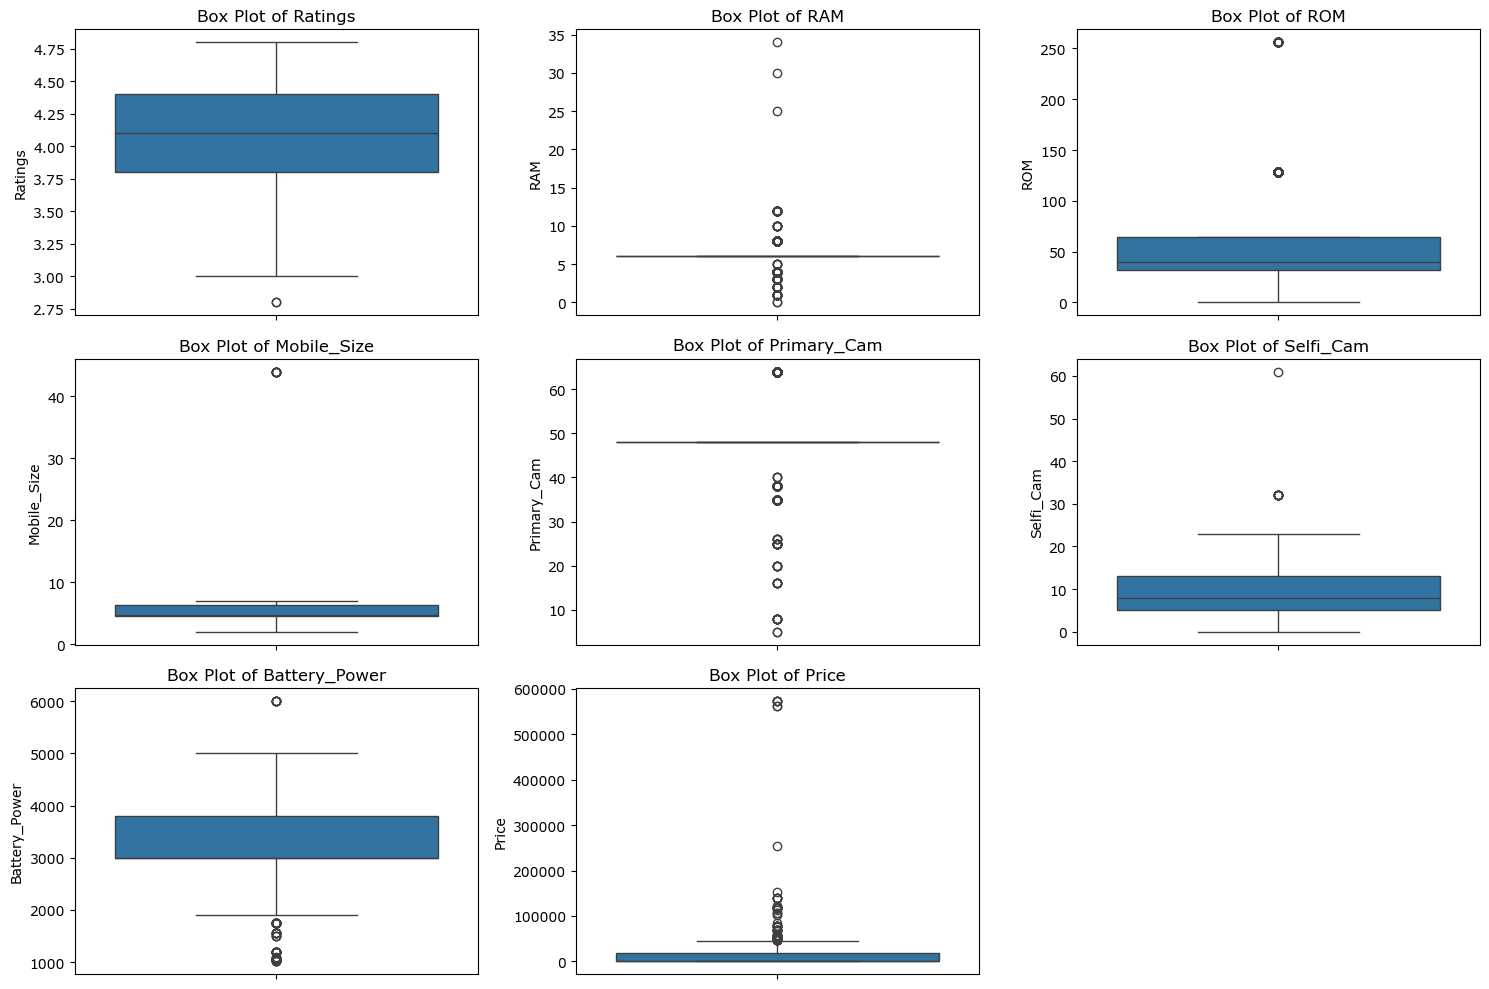

In [5]:
#Boxplots
numerical_features = ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power','Price']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

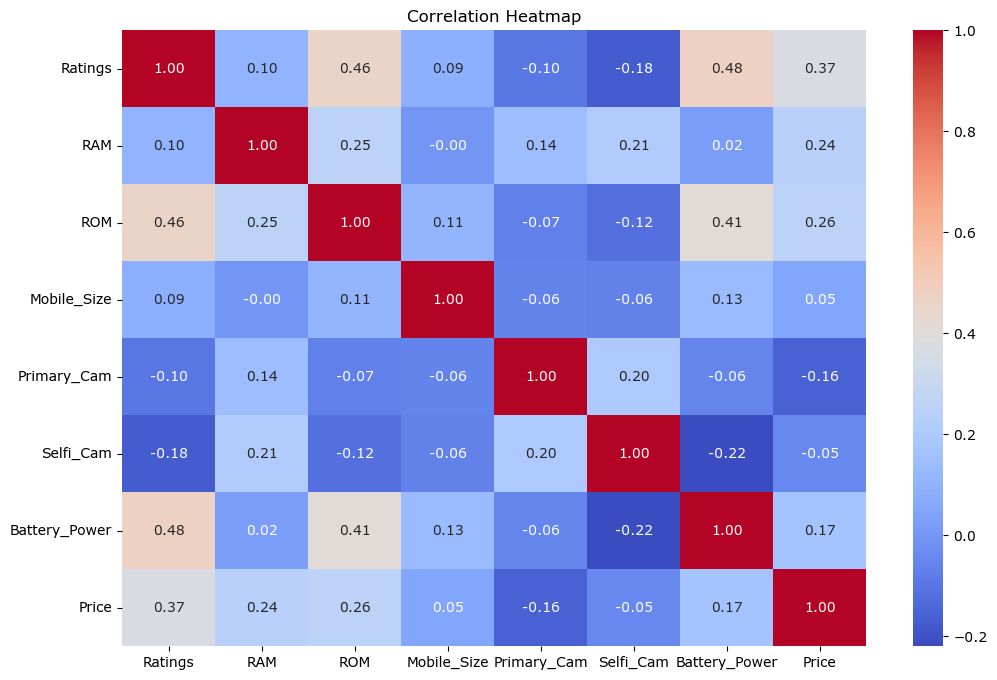

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

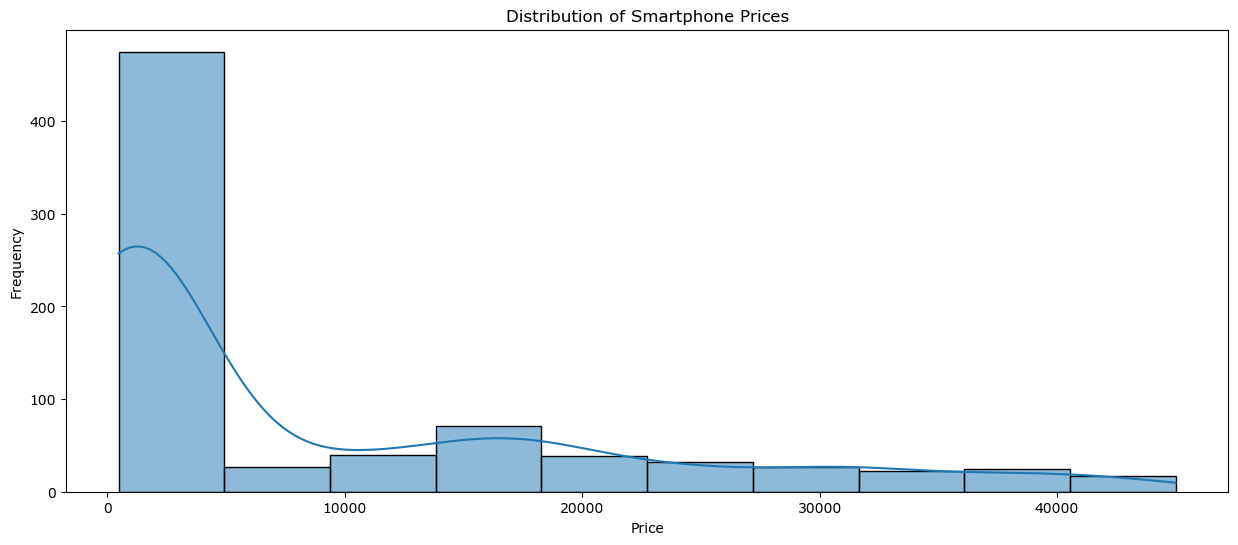

In [10]:
# Distribution of target variable (Price)
plt.figure(figsize=(15, 6))
sns.histplot(df['Price'], bins=10, kde=True)
plt.title('Distribution of Smartphone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

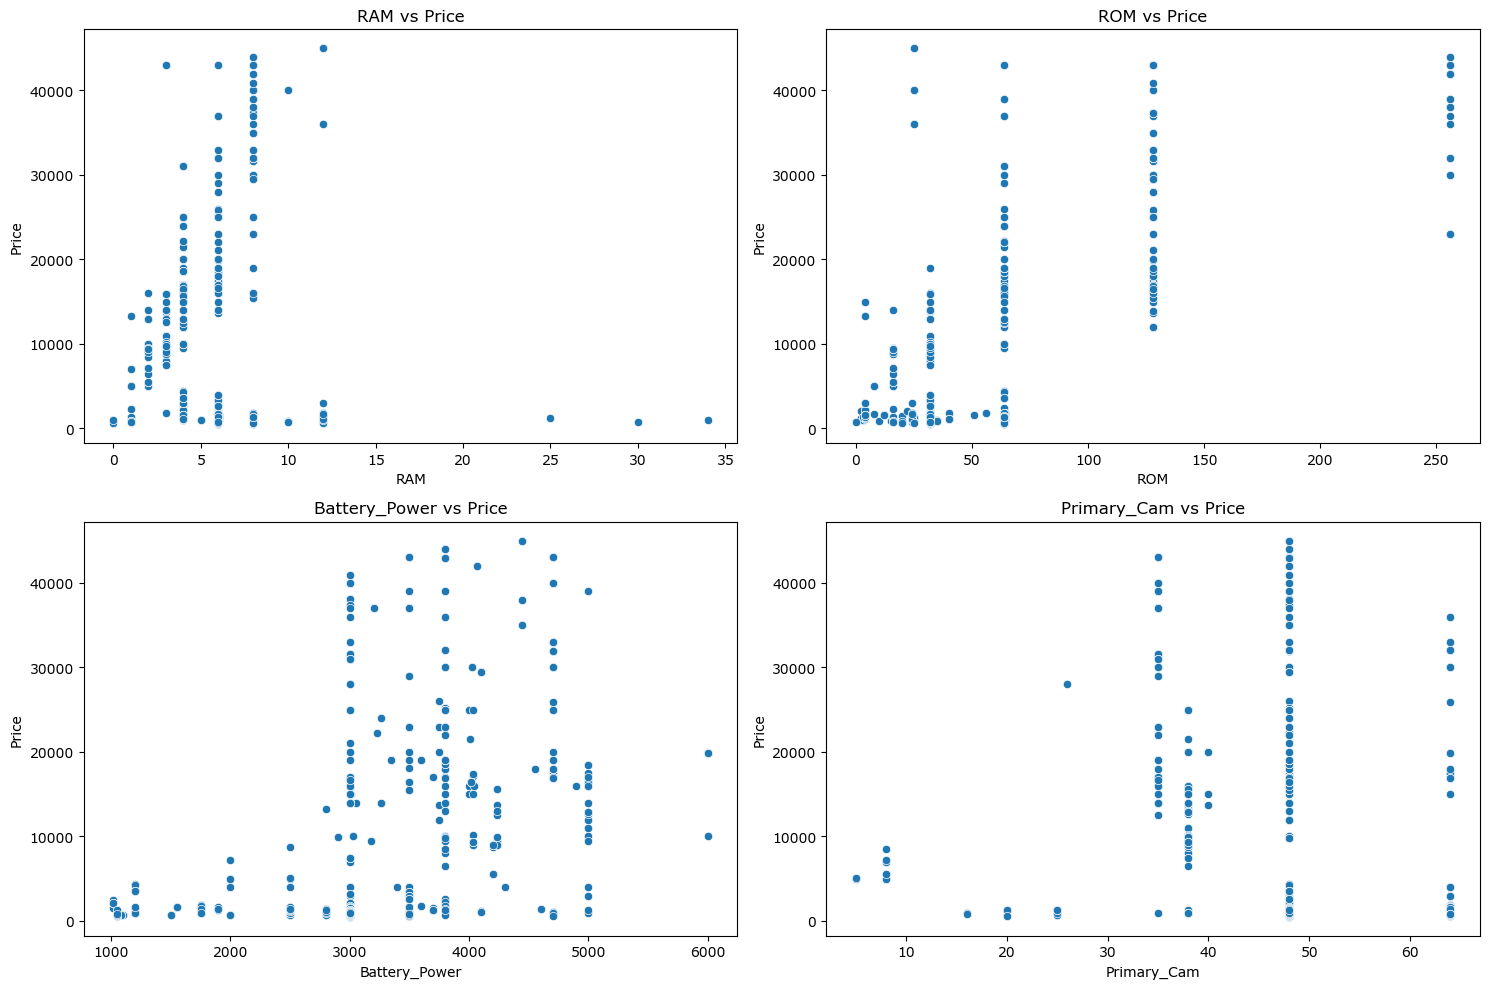

In [11]:
key_features = ['RAM', 'ROM', 'Battery_Power', 'Primary_Cam']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df[feature], y=df['Price'])
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

C:\Users\Sambram\AppData\Local\Temp\ipykernel_2536\2653753728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand'] = df['Brand'].str.split().str[0]



Top Brands by Ratings:
 Brand
Infinix     4.600000
OnePlus     4.517647
Google      4.500000
Motorola    4.500000
Apple       4.500000
POCO        4.500000
Realme      4.500000
Redmi       4.472414
Forme       4.450000
Vivo        4.405000
Name: Ratings, dtype: float64


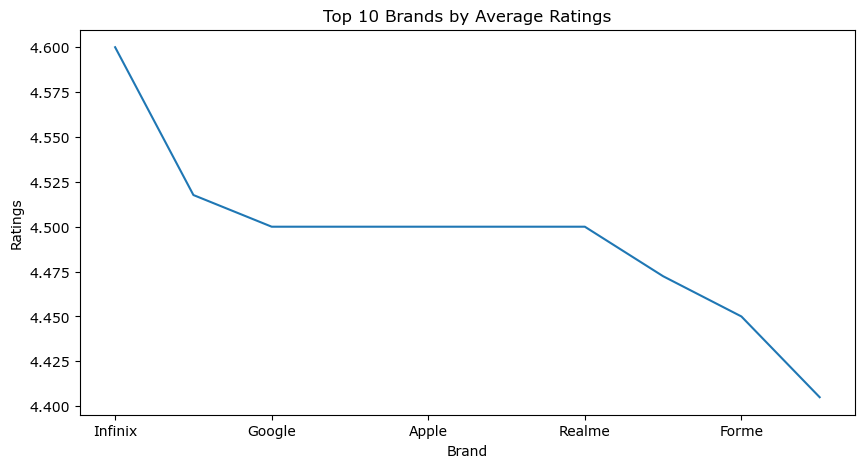

In [12]:
df['Brand'] = df['Brand'].str.split().str[0]

# Average rating per brand
brand_rating = df.groupby('Brand')['Ratings'].mean().sort_values(ascending=False)

print("\nTop Brands by Ratings:\n", brand_rating.head(10))

# Plot
plt.figure(figsize=(10,5))
brand_rating.head(10).plot(kind='line')
plt.title("Top 10 Brands by Average Ratings")
plt.ylabel("Ratings")
plt.show()

In [44]:
#Modelling

X = df.drop("Price", axis=1)
y = df["Price"]

categorical_cols = ["Brand"]
numeric_cols = [col for col in X.columns if col != "Brand"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

In [ ]:
joblib.dump(pipeline, "mobile_price_pipeline.pkl")
print("Model Saved")

 Pipeline Model Saved


In [48]:
pipeline.score(X_test,y_test)

0.8774697667443423

In [49]:
y_pred=pipeline.predict(X_test)
print("Accuracy Score : ",r2_score(y_test,y_pred)*100,"%")

Accuracy Score :  87.74697667443422 %


         Feature  Importance
3            ROM    0.518505
0          Brand    0.254358
1        Ratings    0.099101
2            RAM    0.053622
5    Primary_Cam    0.026727
7  Battery_Power    0.025547
6      Selfi_Cam    0.014643
4    Mobile_Size    0.007497


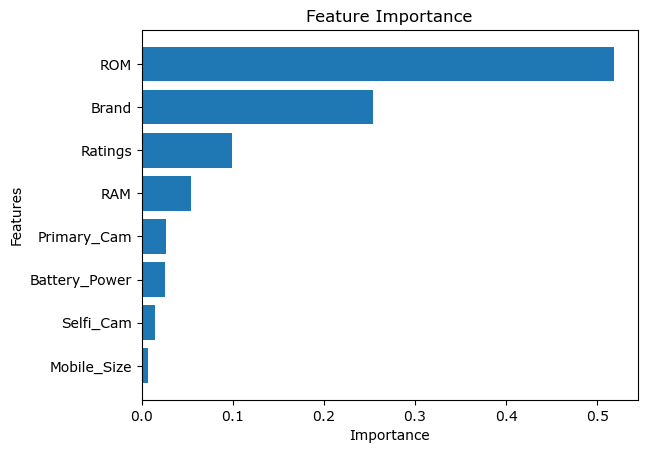

In [51]:
model = pipeline.named_steps['model']
feature_names = X.columns
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)
print(feat_imp)

plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()